 1. Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import os allows Python to interact with your computer’s operating system.
import cv2 lets Python handle images and videos using OpenCV.import numpy as np lets you use NumPy for fast numerical operations with a short name np.import matplotlib.pyplot as plt lets you create graphs easily using the short name plt.Counter helps you count repeated items quickly and easily.

2. Load Dataset Path

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

print("Path to dataset files:", path)

100%|██████████| 107M/107M [00:08<00:00, 13.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1


3. Get Class Names

In [3]:
data_path = path

classes = os.listdir(data_path)
print('Classes:', classes)

Classes: ['Brain Tumor Data Set', 'metadata_rgb_only.csv', 'metadata.csv']


This code lists all contents in the dataset folder, including both files and subfolders.”

In [4]:
data_path = os.path.join(path, "Brain Tumor Data Set")
print(os.listdir(data_path))

['Brain Tumor Data Set']


This code builds a correct folder path and lists all contents inside it.

In [5]:
import os

data_path = os.path.join(path, "Brain Tumor Data Set", "Brain Tumor Data Set")

print(os.listdir(data_path))


['Brain Tumor', 'Healthy']


code joins two same folder names—works only if your dataset actually has nested folders with the same name.

In [6]:
classes = [cls for cls in os.listdir(data_path)
           if os.path.isdir(os.path.join(data_path, cls))]

print("Classes:", classes)

Classes: ['Brain Tumor', 'Healthy']


This code filters only folder names (class labels) and ignores files like CSV.

4. Class Distubution

In [7]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(data_path, cls)

    images = [img for img in os.listdir(class_path)
              if img.endswith(('.jpg', '.png', '.jpeg'))]

    class_counts[cls] = len(images)

print("Class Distribution:", class_counts)

Class Distribution: {'Brain Tumor': 2359, 'Healthy': 2081}


This code counts how many image files are present in each class folder.

5. Plot Class Distribution

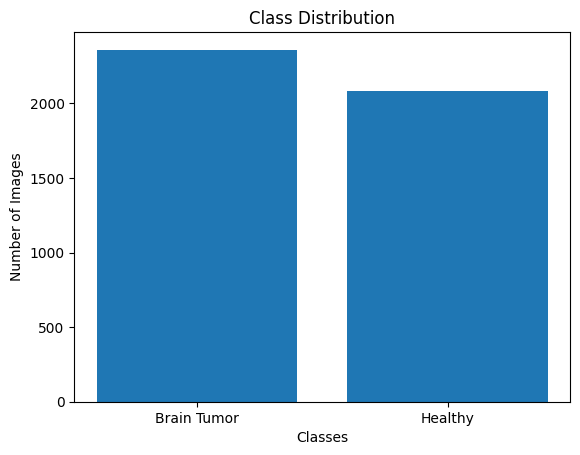

In [8]:
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

This code creates and displays a bar chart showing number of images in each class.

6. Image Size Analysis

In [9]:
sizes = []

for cls in classes:
    class_path = os.path.join(data_path, cls)
    for img_name in os.listdir(class_path)[:100]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            sizes.append(img.shape)

unique_sizes = set(sizes)
print("Unique Image Sizes:", unique_sizes)

Unique Image Sizes: {(279, 258, 3), (243, 236, 3), (530, 380, 3), (250, 201, 3), (442, 442, 3), (323, 276, 3), (630, 628, 3), (354, 318, 3), (355, 272, 3), (725, 728, 3), (392, 331, 3), (630, 630, 3), (614, 630, 3), (228, 235, 3), (236, 236, 3), (513, 565, 3), (340, 288, 3), (1024, 1024, 3), (295, 236, 3), (217, 232, 3), (238, 212, 3), (352, 281, 3), (223, 226, 3), (512, 416, 3), (583, 1000, 3), (442, 400, 3), (243, 207, 3), (336, 300, 3), (295, 283, 3), (340, 339, 3), (252, 200, 3), (345, 338, 3), (251, 204, 3), (555, 526, 3), (512, 512, 3), (222, 212, 3), (349, 292, 3), (359, 297, 3), (357, 236, 3), (361, 642, 3), (340, 314, 3), (277, 272, 3), (248, 200, 3), (334, 283, 3), (231, 218, 3), (406, 339, 3), (222, 227, 3), (310, 246, 3), (269, 249, 3), (168, 300, 3), (365, 306, 3), (745, 850, 3), (291, 253, 3), (243, 205, 3), (337, 293, 3), (355, 294, 3), (286, 241, 3), (454, 442, 3), (229, 235, 3), (194, 259, 3), (300, 240, 3), (280, 236, 3), (236, 214, 3), (201, 173, 3), (242, 208, 3), (

This code finds all different image sizes present in your dataset.

7. Sample Visualization





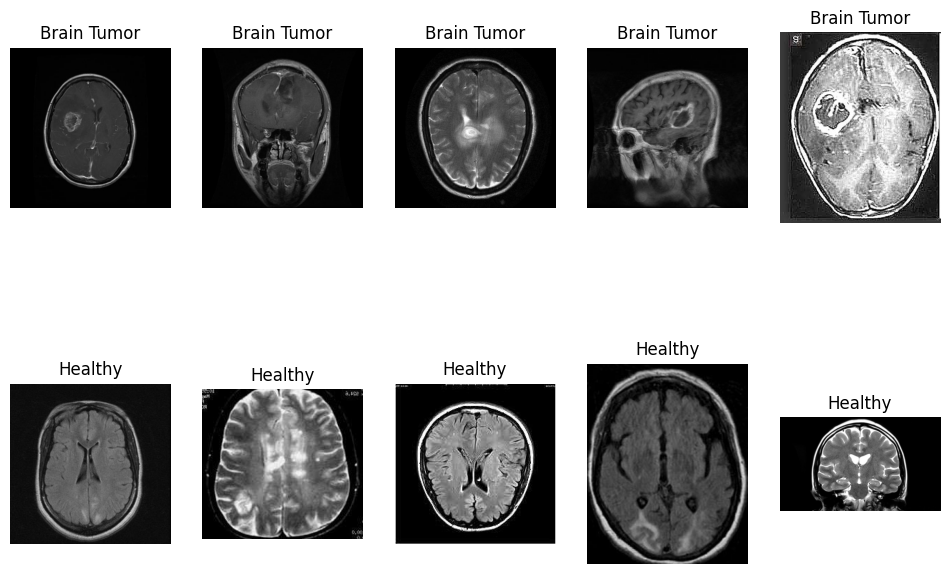

In [10]:
plt.figure(figsize=(12,8))

i = 1
for cls in classes:
    class_path = os.path.join(data_path, cls)

    for img_name in os.listdir(class_path)[:5]:  # 5 images each
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, i)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')
        i += 1

plt.show()

This code displays 5 sample images from each class in a grid for visualization.

8. Check Image Blur (Sharpness)

In [11]:
def check_blur(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance

blur_values = []

for cls in classes:
    class_path = os.path.join(data_path, cls)

    for img_name in os.listdir(class_path)[:50]:  # sample check
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            blur_values.append(check_blur(img))

print("Sample Blur Values:", blur_values[:10])
print("Average Sharpness:", sum(blur_values)/len(blur_values))

Sample Blur Values: [np.float64(47.31580352783203), np.float64(51.131499487673864), np.float64(60.26229024252012), np.float64(35.89016052473744), np.float64(7184.053974976032), np.float64(4353.812229325712), np.float64(866.1164559764809), np.float64(65.97547895874595), np.float64(609.6872962861377), np.float64(72.53054574444832)]
Average Sharpness: 1819.4748611203404


This code measures how sharp or blurry each image is using edge detection.

9. Check Brightness (Pixel Mean)

In [12]:
means = []

for cls in classes:
    class_path = os.path.join(data_path, cls)

    for img_name in os.listdir(class_path)[:50]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            means.append(np.mean(img))

print("Pixel Mean Range:", min(means), "to", max(means))

Pixel Mean Range: 19.375076293945312 to 132.29838242755244


This code finds how bright or dark your images are by calculating average pixel values.

10. Check Contrast

In [13]:
contrast_values = []

for cls in classes:
    class_path = os.path.join(data_path, cls)

    for img_name in os.listdir(class_path)[:50]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            contrast = gray.std()
            contrast_values.append(contrast)

print("Contrast Values:", contrast_values[:10])
print("Average Contrast:", sum(contrast_values)/len(contrast_values))

Contrast Values: [np.float64(31.126107008430765), np.float64(37.220664140170236), np.float64(51.53466282336151), np.float64(43.71821290966894), np.float64(83.73365414525713), np.float64(79.57758031098668), np.float64(76.76647779612048), np.float64(41.26332855302336), np.float64(80.79701837862781), np.float64(35.33509265335473)]
Average Contrast: 60.77669759812228


This code measures how clear or dull your images are using contrast (pixel variation).

Check Dataset Balance

In [14]:
values = list(class_counts.values())
if max(values) / min(values) > 1.5:
    print("⚠️ Dataset is imbalanced → Risk of bias")
else:
    print("✅ Dataset is balanced")

✅ Dataset is balanced


This code checks if one class has significantly more data than another (dataset balance check).

Check Dataset Size

In [15]:
total_images = sum(values)
print("Total Images:", total_images)

if total_images < 1000:
    print("⚠️ Small dataset → Risk of overfitting")
else:
    print("✅ Dataset size is reasonable")

Total Images: 4440
✅ Dataset size is reasonable


Final Summary

In [16]:
print("\n===== FINAL ANALYSIS =====")

print("Class Distribution:", class_counts)
print("Total Images:", total_images)

print("Avg Sharpness:", sum(blur_values)/len(blur_values))
print("Pixel Diversity Range:", min(means), "to", max(means))
print("Avg Contrast:", sum(contrast_values)/len(contrast_values))


===== FINAL ANALYSIS =====
Class Distribution: {'Brain Tumor': 2359, 'Healthy': 2081}
Total Images: 4440
Avg Sharpness: 1819.4748611203404
Pixel Diversity Range: 19.375076293945312 to 132.29838242755244
Avg Contrast: 60.77669759812228


# Day 1 - Dataset Understanding (EDA)
This report includes dataset analysis such as class distribution, image size, visualization, and data quality checks.
## Observations

- The dataset contains 4440 images
- Classes: Brain Tumor (2359), Healthy (2081)
- Slight imbalance present
- Image sizes are different → resizing required
- Data quality is good (high sharpness)
- Pixel variation shows good diversity
- Contrast is good → features visible
- Low risk of underfitting, manageable overfitting risk

“Initially, the dataset folder contained both files and subfolders. After navigating to the correct directory, only class folders were selected using directory filtering. The final classes identified were ‘Brain Tumor’ and ‘Healthy’.”
Summary:
“Overall, the dataset is well-structured and suitable for building a classification model after preprocessing.”